In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
wmt = pd.read_csv('Walmart.csv')

In [3]:
wmt.head()  

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin
0,1,WALM003,San Antonio,Health and beauty,$74.69,7.0,05/01/19,13:08:00,Ewallet,9.1,0.48
1,2,WALM048,Harlingen,Electronic accessories,$15.28,5.0,08/03/19,10:29:00,Cash,9.6,0.48
2,3,WALM067,Haltom City,Home and lifestyle,$46.33,7.0,03/03/19,13:23:00,Credit card,7.4,0.33
3,4,WALM064,Bedford,Health and beauty,$58.22,8.0,27/01/19,20:33:00,Ewallet,8.4,0.33
4,5,WALM013,Irving,Sports and travel,$86.31,7.0,08/02/19,10:37:00,Ewallet,5.3,0.48


In [4]:
wmt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10051 entries, 0 to 10050
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_id      10051 non-null  int64  
 1   Branch          10051 non-null  object 
 2   City            10051 non-null  object 
 3   category        10051 non-null  object 
 4   unit_price      10020 non-null  object 
 5   quantity        10020 non-null  float64
 6   date            10051 non-null  object 
 7   time            10051 non-null  object 
 8   payment_method  10051 non-null  object 
 9   rating          10051 non-null  float64
 10  profit_margin   10051 non-null  float64
dtypes: float64(3), int64(1), object(7)
memory usage: 863.9+ KB


In [5]:
wmt['Branch'].value_counts()

Branch
WALM058    240
WALM009    238
WALM030    233
WALM069    224
WALM074    212
          ... 
WALM013     57
WALM031     56
WALM034     56
WALM014     52
WALM092     51
Name: count, Length: 100, dtype: int64

In [6]:
wmt['City'].value_counts()

City
Weslaco            399
Waxahachie         381
Port Arthur        240
Plano              238
Richardson         233
                  ... 
Irving              57
Lewisville          56
College Station     56
Amarillo            52
Lake Jackson        51
Name: count, Length: 98, dtype: int64

In [7]:
wmt['category'].value_counts()

category
Fashion accessories       4579
Home and lifestyle        4561
Electronic accessories     419
Food and beverages         174
Sports and travel          166
Health and beauty          152
Name: count, dtype: int64

In [8]:
wmt['category'].value_counts().sum()

np.int64(10051)

In [9]:
wmt.describe()

,invoice_id,quantity,rating,profit_margin
count,10051.000000,10020.000000,10051.000000,10051.000000
mean,5025.741220,2.353493,5.825659,0.393791
std,2901.174372,1.602658,1.763991,0.090669
min,1.000000,1.000000,3.000000,0.180000
25%,2513.500000,1.000000,4.000000,0.330000
50%,5026.000000,2.000000,6.000000,0.330000
75%,7538.500000,3.000000,7.000000,0.480000
max,10000.000000,10.000000,10.000000,0.570000


In [10]:
wmt.isnull().sum()

invoice_id         0
Branch             0
City               0
category           0
unit_price        31
quantity          31
date               0
time               0
payment_method     0
rating             0
profit_margin      0
dtype: int64

In [11]:
wmt.dropna(inplace=True)   

In [12]:
wmt.duplicated().sum()

np.int64(51)

In [13]:
wmt.drop_duplicates(inplace=True)

In [14]:
wmt.duplicated().sum()

np.int64(0)

In [15]:
wmt.shape

(9969, 11)

> previously the shape was( 10051, 11) and now after dropping duplicates and null values the shape is (9969, 11)

In [16]:
wmt['unit_price']

0       $74.69
1       $15.28
2       $46.33
3       $58.22
4       $86.31
         ...  
9995       $37
9996       $58
9997       $52
9998       $79
9999       $62
Name: unit_price, Length: 9969, dtype: object

In [17]:
# now changing the datatype of the column unit_price and removing the $ sign from the column unit_price such that it can be converted to float datatype and then we can perform some analysis on it.

In [18]:
wmt['unit_price'] = wmt['unit_price'].str.replace('$', '').astype(float)

In [19]:
wmt['unit_price']

0       74.69
1       15.28
2       46.33
3       58.22
4       86.31
        ...  
9995    37.00
9996    58.00
9997    52.00
9998    79.00
9999    62.00
Name: unit_price, Length: 9969, dtype: float64

In [20]:
wmt.head()

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin
0,1,WALM003,San Antonio,Health and beauty,74.69,7.0,05/01/19,13:08:00,Ewallet,9.1,0.48
1,2,WALM048,Harlingen,Electronic accessories,15.28,5.0,08/03/19,10:29:00,Cash,9.6,0.48
2,3,WALM067,Haltom City,Home and lifestyle,46.33,7.0,03/03/19,13:23:00,Credit card,7.4,0.33
3,4,WALM064,Bedford,Health and beauty,58.22,8.0,27/01/19,20:33:00,Ewallet,8.4,0.33
4,5,WALM013,Irving,Sports and travel,86.31,7.0,08/02/19,10:37:00,Ewallet,5.3,0.48


In [21]:
wmt['total_cost'] = wmt['unit_price'] * wmt['quantity']

In [22]:
wmt['total_cost']

0       522.83
1        76.40
2       324.31
3       465.76
4       604.17
         ...  
9995    111.00
9996    116.00
9997    156.00
9998    158.00
9999    186.00
Name: total_cost, Length: 9969, dtype: float64

In [23]:
wmt.head()

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin,total_cost
0,1,WALM003,San Antonio,Health and beauty,74.69,7.0,05/01/19,13:08:00,Ewallet,9.1,0.48,522.83
1,2,WALM048,Harlingen,Electronic accessories,15.28,5.0,08/03/19,10:29:00,Cash,9.6,0.48,76.40
2,3,WALM067,Haltom City,Home and lifestyle,46.33,7.0,03/03/19,13:23:00,Credit card,7.4,0.33,324.31
3,4,WALM064,Bedford,Health and beauty,58.22,8.0,27/01/19,20:33:00,Ewallet,8.4,0.33,465.76
4,5,WALM013,Irving,Sports and travel,86.31,7.0,08/02/19,10:37:00,Ewallet,5.3,0.48,604.17


In [24]:
wmt.rename(columns={'total_cost': 'Total Price based on total quantity sold'}, inplace=True)

In [25]:
wmt.head()

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin,Total Price based on total quantity sold
0,1,WALM003,San Antonio,Health and beauty,74.69,7.0,05/01/19,13:08:00,Ewallet,9.1,0.48,522.83
1,2,WALM048,Harlingen,Electronic accessories,15.28,5.0,08/03/19,10:29:00,Cash,9.6,0.48,76.40
2,3,WALM067,Haltom City,Home and lifestyle,46.33,7.0,03/03/19,13:23:00,Credit card,7.4,0.33,324.31
3,4,WALM064,Bedford,Health and beauty,58.22,8.0,27/01/19,20:33:00,Ewallet,8.4,0.33,465.76
4,5,WALM013,Irving,Sports and travel,86.31,7.0,08/02/19,10:37:00,Ewallet,5.3,0.48,604.17


In [26]:
wmt['Profit earned'] = wmt['Total Price based on total quantity sold']*wmt['profit_margin']

In [27]:
wmt['Profit earned']

0       250.9584
1        36.6720
2       107.0223
3       153.7008
4       290.0016
          ...   
9995     36.6300
9996     55.6800
9997     74.8800
9998     75.8400
9999     61.3800
Name: Profit earned, Length: 9969, dtype: float64

In [28]:
wmt.head(10)

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin,Total Price based on total quantity sold,Profit earned
0,1,WALM003,San Antonio,Health and beauty,74.69,7.0,05/01/19,13:08:00,Ewallet,9.1,0.48,522.83,250.9584
1,2,WALM048,Harlingen,Electronic accessories,15.28,5.0,08/03/19,10:29:00,Cash,9.6,0.48,76.40,36.6720
2,3,WALM067,Haltom City,Home and lifestyle,46.33,7.0,03/03/19,13:23:00,Credit card,7.4,0.33,324.31,107.0223
3,4,WALM064,Bedford,Health and beauty,58.22,8.0,27/01/19,20:33:00,Ewallet,8.4,0.33,465.76,153.7008
4,5,WALM013,Irving,Sports and travel,86.31,7.0,08/02/19,10:37:00,Ewallet,5.3,0.48,604.17,290.0016
5,6,WALM026,Denton,Electronic accessories,85.39,7.0,25/03/19,18:30:00,Ewallet,4.1,0.48,597.73,286.9104
6,7,WALM088,Cleburne,Electronic accessories,68.84,6.0,25/02/19,14:36:00,Ewallet,5.8,0.33,413.04,136.3032
7,8,WALM100,Canyon,Home and lifestyle,73.56,10.0,24/02/19,11:38:00,Ewallet,8.0,0.18,735.60,132.4080
8,9,WALM066,Grapevine,Health and beauty,36.26,2.0,10/01/19,17:15:00,Credit card,7.2,0.33,72.52,23.9316
9,10,WALM065,Texas City,Food and beverages,54.84,3.0,20/02/19,13:27:00,Credit card,5.9,0.33,164.52,54.2916


Text(0.5, 1.0, 'Total Price based on total quantity sold for each category')

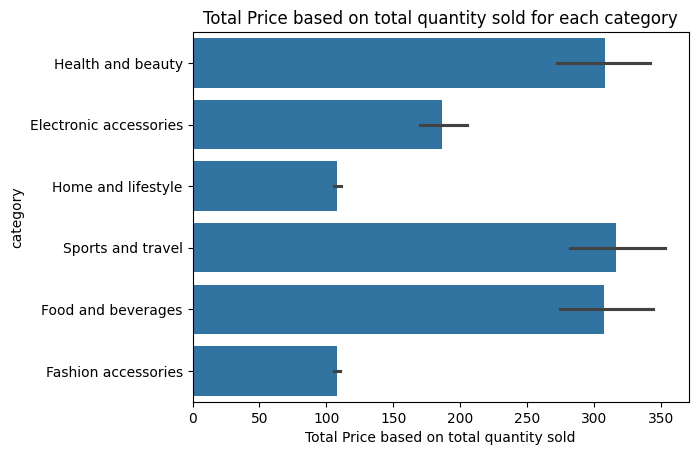

In [29]:
sns.barplot(y='category', x='Total Price based on total quantity sold', data=wmt)
plt.title('Total Price based on total quantity sold for each category')

> from the above analysis sports and travel category has the highest total price based on total quantity sold and fashion accessories has the lowest total price based on total quantity sold.

<Axes: xlabel='Count', ylabel='payment_method'>

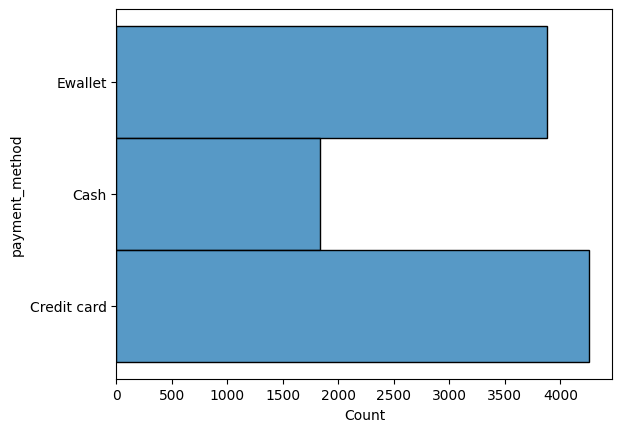

In [30]:
sns.histplot(y='payment_method',  data=wmt)

> credit card is the most used payment method in Walmart followed by E-wallet and cash payment is the least faavourable payment mtd. .

Text(0.5, 1.0, 'Total number of items sold for each category')

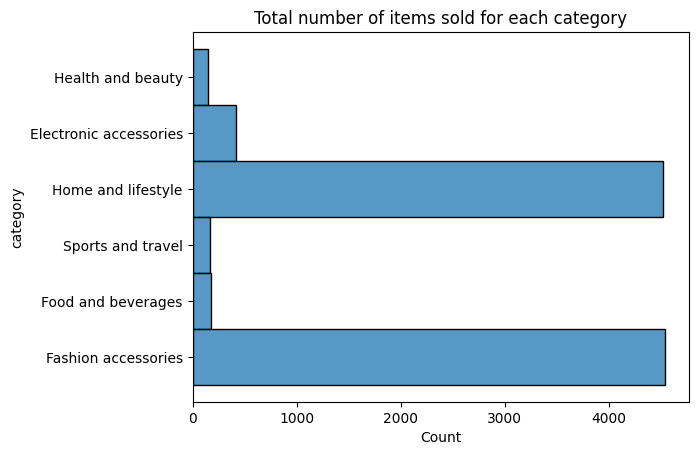

In [31]:
sns.histplot(y='category', data=wmt)
plt.title('Total number of items sold for each category')

> fashion category has the highest total price based on total quantity sold.
>
> whereas home and lifestyle where the 2nd most highest sales from item sold in the walmart store.
>
> and least sales item where health and beauty category.
>in the walmart

In [32]:
count_fashion = (wmt['category'] == 'Fashion accessories').sum()
count_fashion

np.int64(4538)

In [33]:
wmt[(wmt['category'] == 'Fashion accessories') & (wmt['payment_method'] == 'Credit card')].count()

invoice_id                                  1917
Branch                                      1917
City                                        1917
category                                    1917
unit_price                                  1917
quantity                                    1917
date                                        1917
time                                        1917
payment_method                              1917
rating                                      1917
profit_margin                               1917
Total Price based on total quantity sold    1917
Profit earned                               1917
dtype: int64

In [34]:
wmt[(wmt['category'] == 'Fashion accessories') & (wmt['payment_method'] == 'Cash')].count()

invoice_id                                  799
Branch                                      799
City                                        799
category                                    799
unit_price                                  799
quantity                                    799
date                                        799
time                                        799
payment_method                              799
rating                                      799
profit_margin                               799
Total Price based on total quantity sold    799
Profit earned                               799
dtype: int64

In [35]:
wmt[(wmt['category'] == 'Fashion accessories') & (wmt['payment_method'] == 'Ewallet')].count()

invoice_id                                  1822
Branch                                      1822
City                                        1822
category                                    1822
unit_price                                  1822
quantity                                    1822
date                                        1822
time                                        1822
payment_method                              1822
rating                                      1822
profit_margin                               1822
Total Price based on total quantity sold    1822
Profit earned                               1822
dtype: int64

> from the above analysis we can conclude that the most preferred payment method for the most sold categories: 'Fashion accessories' is Credit card.

In [36]:
wmt.to_csv('Walmart_cleaned.csv', index=False)

>> sql data transformation part start ffrom here  ⏬⏬

In [37]:
from sqlalchemy import create_engine